# Fraud Detection

**Selected Machine Learning Exercise**

Binary classification project for detecting fraudulent transactions with an SVM pipeline.

In [2]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("data/fraud_train.csv")

In [26]:
df.shape

(7840, 31)

In [27]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,8365.0,-0.655093,1.102283,1.610914,2.542440,0.928295,0.344427,0.340831,-0.004130,-0.039325,...,0.025710,0.297263,-0.195074,-0.476353,-0.269339,0.154728,-0.004028,0.155044,16.93,0.0
1,10222.0,-0.643681,0.953126,2.223666,1.134587,-0.198051,0.435065,0.221857,0.017773,1.931767,...,-0.066355,0.684519,-0.210179,0.036703,-0.126450,-0.199370,0.377610,0.033734,20.24,0.0
2,35866.0,-2.044489,3.368306,-3.937111,5.623120,-3.079232,-1.253474,-5.778880,1.707428,-4.467103,...,1.483594,0.834311,-0.148486,0.001669,-0.038996,0.389526,1.300236,0.549940,7.61,1.0
3,10836.0,1.020913,-0.400279,0.662579,0.341929,-0.656141,-0.021927,-0.386604,0.054592,1.820545,...,-0.131286,-0.065529,-0.067101,0.260703,0.253718,1.066000,-0.096361,-0.005774,79.95,0.0
4,69.0,0.298503,2.142722,-1.542143,1.561332,0.938108,-2.145673,1.405569,-0.778459,0.328636,...,-0.290987,-0.000235,0.092174,0.586205,-0.397314,-0.480949,0.251145,-0.242279,0.78,0.0


In [28]:
df.duplicated().sum()

np.int64(33)

In [29]:
df.duplicated(keep=False).sum()

np.int64(56)

In [30]:
duplicates = df[df.duplicated(keep=False)]

print(duplicates.shape)
duplicates.sort_values(["Time", "Amount"])

(56, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
4269,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
4303,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
4786,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0.0
830,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0.0
3133,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0.0
3367,145.0,-2.419486,1.949346,0.552998,0.982710,-0.284815,2.411200,-1.398537,-0.188922,0.675695,...,1.213390,-1.238354,0.007191,-1.724175,0.239721,-0.313607,-0.187431,0.119472,6.74,0.0
5801,145.0,-2.419486,1.949346,0.552998,0.982710,-0.284815,2.411200,-1.398537,-0.188922,0.675695,...,1.213390,-1.238354,0.007191,-1.724175,0.239721,-0.313607,-0.187431,0.119472,6.74,0.0
710,1074.0,-2.445204,-0.505494,0.164511,-0.449658,0.460784,-0.509035,-0.490478,1.060597,-0.385591,...,0.060361,-0.802101,-0.299229,-0.831608,-0.055518,0.315454,-0.467257,-0.167591,1.00,0.0
1210,1074.0,-2.445204,-0.505494,0.164511,-0.449658,0.460784,-0.509035,-0.490478,1.060597,-0.385591,...,0.060361,-0.802101,-0.299229,-0.831608,-0.055518,0.315454,-0.467257,-0.167591,1.00,0.0
3769,1308.0,-1.322313,0.863591,1.844234,1.089375,0.771005,0.152191,1.491514,-0.917308,0.765538,...,-0.340315,0.315702,-0.133591,0.107112,0.246560,-0.309290,-0.510963,-0.349976,25.30,0.0


In [31]:
df["Class"].value_counts()

Class
0.0    7471
1.0     369
Name: count, dtype: int64

In [32]:
duplicates["Class"].value_counts()

Class
0.0    44
1.0    12
Name: count, dtype: int64

In [33]:
df = df.drop_duplicates()

In [34]:
df.duplicated().sum()

np.int64(0)

## after dimensionality reduction, features become less correlated

In [10]:
corr = df.corr()
corr

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,-0.220431,0.242132,-0.460073,0.397195,-0.175341,-0.171868,-0.325021,0.005769,-0.286398,...,0.040737,0.101748,0.002417,-0.049782,-0.064017,0.050754,-0.005563,0.055475,0.066327,0.812236
V1,-0.220431,1.000000,-0.458741,0.568748,-0.295541,0.412061,0.161868,0.583481,0.008552,0.289759,...,-0.025225,-0.084214,-0.065054,-0.014655,0.127147,0.039867,-0.023548,0.084984,-0.139721,-0.395934
V2,0.242132,-0.458741,1.000000,-0.553190,0.338685,-0.451428,-0.093210,-0.450828,-0.045328,-0.377711,...,0.065637,-0.025536,0.072346,-0.023773,-0.099263,-0.073354,-0.046358,-0.033018,-0.347647,0.398123
V3,-0.460073,0.568748,-0.553190,1.000000,-0.450218,0.558889,0.140863,0.723726,-0.152443,0.536346,...,-0.000866,0.035408,-0.018437,0.027208,-0.103450,0.045388,-0.056311,-0.012698,-0.112071,-0.670165
V4,0.397195,-0.295541,0.338685,-0.450218,1.000000,-0.346477,-0.130729,-0.441854,0.090233,-0.424867,...,-0.015438,0.069811,-0.003695,-0.063260,-0.051357,0.046739,0.023879,0.001495,0.109174,0.510243
V5,-0.175341,0.412061,-0.451428,0.558889,-0.346477,1.000000,0.153226,0.480384,-0.100484,0.318475,...,-0.001951,-0.136302,-0.074367,-0.006796,-0.031717,-0.070236,0.049558,-0.054802,-0.311222,-0.354461
V6,-0.171868,0.161868,-0.093210,0.140863,-0.130729,0.153226,1.000000,0.150076,-0.164466,0.116589,...,-0.003780,-0.032845,0.084623,0.032562,0.067538,-0.033126,-0.096669,-0.008367,0.222504,-0.234753
V7,-0.325021,0.583481,-0.450828,0.723726,-0.441854,0.480384,0.150076,1.000000,0.047387,0.431627,...,0.019606,-0.085009,0.013453,-0.003260,0.004790,-0.036513,0.011926,0.023490,0.178400,-0.503819
V8,0.005769,0.008552,-0.045328,-0.152443,0.090233,-0.100484,-0.164466,0.047387,1.000000,-0.095606,...,-0.020089,-0.006758,-0.165564,0.013584,0.113314,0.021723,0.167073,0.067041,-0.047150,0.110220
V9,-0.286398,0.289759,-0.377711,0.536346,-0.424867,0.318475,0.116589,0.431627,-0.095606,1.000000,...,0.031106,-0.072081,-0.027096,0.018784,0.106021,0.129298,-0.037056,-0.066111,-0.028792,-0.501505


## Inspecting outliers

In [40]:
from sklearn.model_selection import train_test_split 

x = df.drop(columns=["Class"])
y = df["Class"]

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [49]:
results = []
train = x_train.copy()
train["Class"] = y_train.values
feature_cols = [f"V{i}" for i in range(1, 29)]

for col in feature_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = (train[col] < lower) | (train[col] > upper)

    normal_mask = train["Class"] == 0
    fraud_mask = train["Class"] == 1

    results.append({
        "feature": col,
        "total_outliers": outlier.sum(),

        "normal_outliers": (outlier & normal_mask).sum(),
        "fraud_outliers": (outlier & fraud_mask).sum(),

        "normal_outlier_pct":
            100 * outlier[normal_mask].mean(),

        "fraud_outlier_pct":
            100 * outlier[fraud_mask].mean()
    })

outlier_class_summary = pd.DataFrame(results)

In [51]:
outlier_class_summary.sort_values("normal_outlier_pct", ascending=False)

,feature,total_outliers,normal_outliers,fraud_outliers,normal_outlier_pct,fraud_outlier_pct
27,V28,1118,944,174,15.852225,60.000000
5,V6,629,543,86,9.118388,29.655172
19,V20,651,533,118,8.950462,40.689655
7,V8,657,505,152,8.480269,52.413793
26,V27,667,497,170,8.345928,58.620690
20,V21,592,400,192,6.717045,66.206897
22,V23,485,380,105,6.381192,36.206897
4,V5,515,372,143,6.246851,49.310345
1,V2,431,284,147,4.769102,50.689655
9,V10,503,268,235,4.500420,81.034483


1. `normal_outlier_pct` (low) vs `fraud_outlier_pct` (high)

2. `normal_outlier_pct` (high) vs `fraud_outlier_pct` (low)

3. `normal_outlier_pct` (medium) vs `fraud_outlier_pct` (medium)

## 1. `normal_outlier_pct` (low) vs `fraud_outlier_pct` (high)

 | Feature | Normal outlier % | Fraud outlier % |       اختلاف |
| ------- | ---------------: | --------------: | -----------: |
| **V14** |            1.49% |      **84.83%** | **83.33 pp** |
| **V3**  |            2.25% |      **81.38%** | **79.13 pp** |
| **V17** |            1.61% |      **78.62%** | **77.01 pp** |
| **V16** |            1.06% |      **67.24%** | **66.18 pp** |
| **V7**  |            2.27% |      **63.45%** | **61.18 pp** |
| **V4**  |            1.11% |      **53.79%** | **52.68 pp** |
| **V9**  |            1.38% |      **50.69%** | **49.31 pp** |
| **V12** |        **0.00%** |      **43.10%** | **43.10 pp** |
| **V11** |            0.10% |      **39.66%** | **39.55 pp** |
| **V1**  |            1.53% |      **33.79%** | **32.26 pp** |


we must keep them as they are. They are quite informative. removing them would bring about the deletion of the majority of the fraud transactions

## 2. `normal_outlier_pct` (high) vs `fraud_outlier_pct` (low)

| Feature | Normal outlier % | Fraud outlier % | Difference (Fraud − Normal) |
| ------- | ---------------: | --------------: | --------------------------: |
| **V24** |            1.61% |           0.69% |                    -0.92 pp |
| **V15** |            1.78% |           1.38% |                    -0.40 pp |
| **V26** |            0.10% |           0.00% |                    -0.10 pp |


It exhibits transaction that are normal and legal, demonstrating not all wierd transactions are illegal. But it's better to inspect `v24`

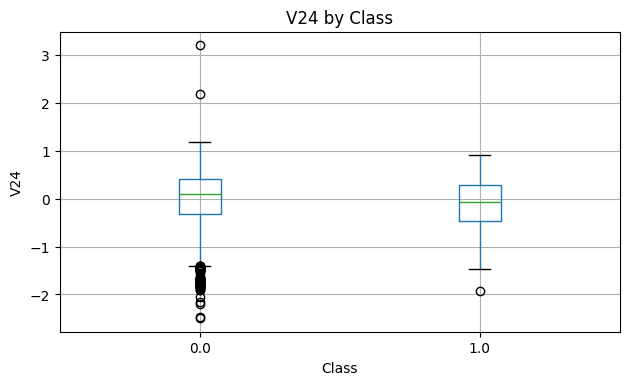

In [52]:
import matplotlib.pyplot as plt

train.boxplot(
    column="V24",
    by="Class",
    figsize=(7, 4)
)

plt.title("V24 by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("V24")
plt.show()

In [53]:
col = "V24"

Q1 = train[col].quantile(0.25)
Q3 = train[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower)
print("Upper:", upper)

print(
    "Normal below:",
    ((train[col] < lower) & (train["Class"] == 0)).sum()
)

print(
    "Normal above:",
    ((train[col] > upper) & (train["Class"] == 0)).sum()
)

print(
    "Fraud below:",
    ((train[col] < lower) & (train["Class"] == 1)).sum()
)

print(
    "Fraud above:",
    ((train[col] > upper) & (train["Class"] == 1)).sum()
)

Lower: -1.4313816329964946
Upper: 1.5172047171004857
Normal below: 94
Normal above: 2
Fraud below: 2
Fraud above: 0


## 3. `normal_outlier_pct` (medium) vs `fraud_outlier_pct` (medium)
| Feature | Normal outlier % | Fraud outlier % | Absolute difference |
| ------- | ---------------: | --------------: | ------------------: |
| **V26** |            0.10% |           0.00% |            **0.10** |
| **V15** |            1.78% |           1.38% |            **0.40** |
| **V13** |            0.10% |           0.69% |            **0.59** |
| **V24** |            1.61% |           0.69% |            **0.92** |

But the absolute rates are both tiny, and the actual counts were only:

Normal outliers: 6
Fraud outliers:  2

## no outliers were removed

## training the model

In [54]:
df[["Time", "Amount"]].head()

,Time,Amount
0,8365.0,16.93
1,10222.0,20.24
2,35866.0,7.61
3,10836.0,79.95
4,69.0,0.78


In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), ["Time", "Amount"])
    ],
    remainder="passthrough"
)

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC())
])

In [64]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform

param_distributions = {
    "model__C": loguniform(1e-2, 1e2),
    "model__gamma": loguniform(1e-4, 1),
    "model__kernel": ["rbf"],
    "model__class_weight": [None, "balanced"]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=param_distributions, n_iter=25, scoring="f1", cv=cv, n_jobs=-1, random_state=42, verbose=2)

In [65]:
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,"Pipeline(step...del', SVC())])"
,param_distributions,"{'model__C': <scipy.stats....001DE96ABF080>, 'model__class_weight': [None, 'balanced'], 'model__gamma': <scipy.stats....001DE9B0D95E0>, 'model__kernel': ['rbf']}"
,n_iter,25
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
print(random_search.best_params_)
print(random_search.best_estimator_)

{'model__C': np.float64(85.68869785189007), 'model__class_weight': None, 'model__gamma': np.float64(0.00015339162591163628), 'model__kernel': 'rbf'}
0.9878840062573531
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['Time', 'Amount'])])),
                ('model',
                 SVC(C=np.float64(85.68869785189007),
                     gamma=np.float64(0.00015339162591163628)))])


* average of F1 through cross validation on training set

In [70]:
print(random_search.best_score_)

0.9878840062573531


In [68]:
best_model = random_search.best_estimator_

In [69]:
from sklearn.metrics import f1_score

best_model = random_search.best_estimator_

y_val_pred = best_model.predict(x_val)

val_f1 = f1_score(y_val, y_val_pred)

print("Validation F1:", val_f1)

Validation F1: 0.993006993006993


In [71]:
best_params = random_search.best_params_

In [72]:
from sklearn.base import clone

final_model = clone(best_model)

final_model.fit(x, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
x_test = pd.read_csv("data/fraud_test.csv")

In [74]:
test_pred = final_model.predict(x_test)

In [82]:
model = final_model.named_steps["model"]

print(type(model))

assert isinstance(model, SVC)

<class 'sklearn.svm._classes.SVC'>


In [83]:
fitted_preprocessor = final_model.named_steps["preprocessor"]

x_test_processed = fitted_preprocessor.transform(x_test)

In [ ]:
from pathlib import Path
Path("outputs").mkdir(exist_ok=True)

submission = pd.DataFrame({
    "Class": test_pred.astype(int)
})

submission.to_csv("outputs/submission.csv", index=False)

print(submission.head())
print(submission["Class"].value_counts())

In [84]:
test_pred = model.predict(x_test_processed)

In [ ]:
import joblib

joblib.dump(final_model, "outputs/fraud_detection_pipeline.joblib")

In [ ]:
import zipfile

artifact_files = [
    "outputs/fraud_detection_pipeline.joblib",
    "outputs/submission.csv",
]

with zipfile.ZipFile("outputs/model_artifacts.zip", mode="w", compression=zipfile.ZIP_DEFLATED) as zf:
    for file_name in artifact_files:
        zf.write(file_name, arcname=Path(file_name).name)

print("Created outputs/model_artifacts.zip")